In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline


In [2]:
df = pd.read_csv ("amz_uk_price_prediction_dataset.csv")

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

In [5]:
# 1. Frequency Table
# 1.1. Generate a frequency table for the product category.
category_frequency = df["category"].value_counts(ascending=False)
category_frequency

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [6]:
category_frequency = df["category"].value_counts(ascending=False).reset_index()
category_frequency.columns =  ['Product_Category', 'Number_of_Items']
category_frequency

,Product_Category,Number_of_Items
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Motorbike Chassis,107
292,Alexa Built-In Devices,107
293,Plugs,107
294,Smart Home Security & Lighting,104


1.2. Which are the top 5 most listed product categories?
* 1 Sports & Outdoors
* 2 Beauty
* 3 Handmade Clothing, Shoes & Accessories	
* 4 Bath & Body	
* 5 Birthday Gifts

In [9]:
#Top 5 product categories
top5 = category_frequency.head(5)
top5

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

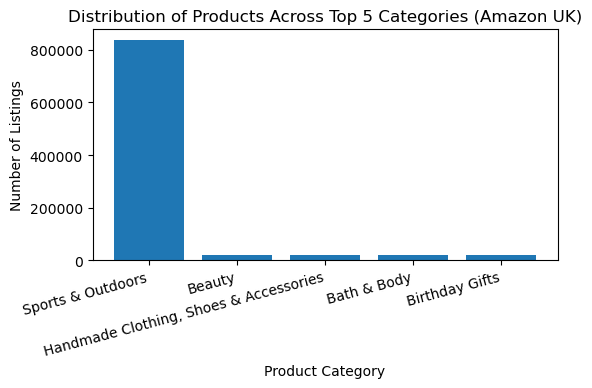

In [14]:
# 2. Visualizations:
# 2.1. Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(top5.index, top5.values)
ax.set_title("Distribution of Products Across Top 5 Categories (Amazon UK)")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Listings")
plt.xticks(rotation=15, ha="right")
plt.show()


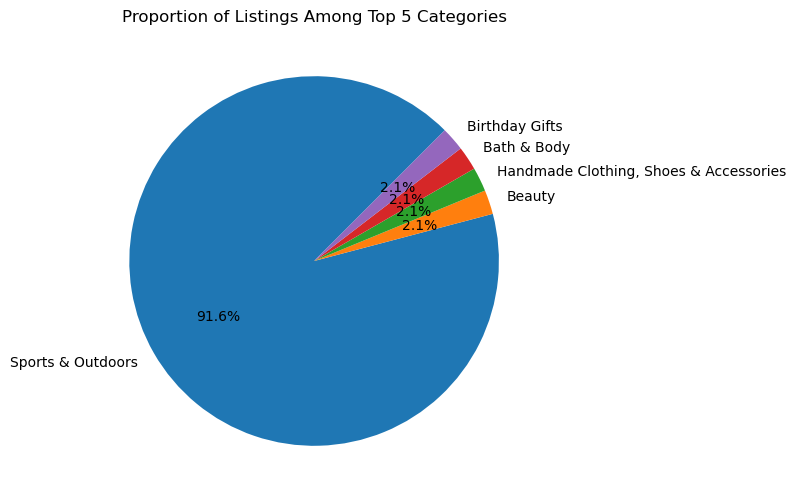

In [17]:
#2.2.For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie( top5.values, labels=top5.index, autopct="%1.1f%%", startangle=45)
ax.set_title("Proportion of Listings Among Top 5 Categories")
plt.show()

Sports and Outdoors category dominates the listing.

# Part 2

Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

In [ ]:
#2.1.
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [20]:
df['price'].isna().sum()

np.int64(0)

In [30]:
df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [24]:
print( "mean price: ", df['price'].mean())
print( "median price: ", df['price'].median())
print( "mode price: ", df['price'].mode()[0])

mean price:  89.24380943923663
median price:  19.09
mode price:  9.99


The average (mean) price of products listed on Amazon UK is approximately £89.2 .

The most common price point (mode) is £9.99, Mean > Mode means expensive outliers pulling the average up, Median < Mean means right-skewed distribution. This means while many products are priced at lower values, a smaller number of higher-priced products increases the overall average.

In [ ]:
#2.2.
print( "price variance: ", df['price'].var())
print( "price std:", df['price'].std())
print( "price range", (df['price'].max()) - (df['price'].min()))

price variance:  119445.48532256528
price std: 345.60886175352226
price range 100000.0


In [28]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
Q1, Q3, IQR

(np.float64(9.99), np.float64(45.99), np.float64(36.0))

Product prices on Amazon UK show a high degree of variability. The large standard deviation, wide price range, and sizable interquartile range all indicate a significant spread in prices, suggesting a diverse marketplace with both budget and premium products.

In [29]:
#2.3.
df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

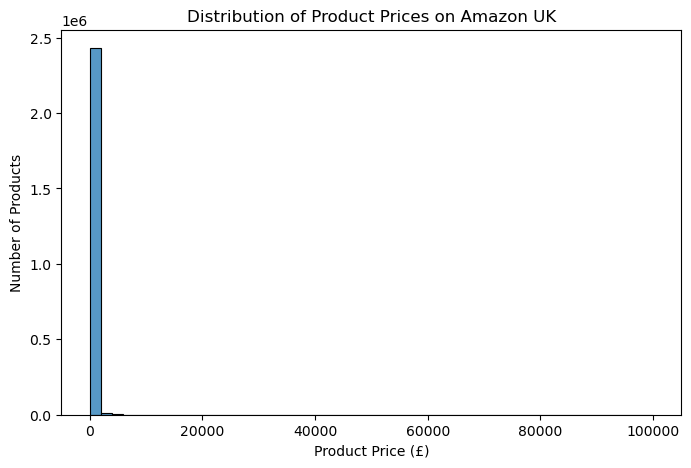

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=False)
plt.xlabel("Product Price (£)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Prices on Amazon UK")
plt.show()

The histogram is difficult to interpret because a small number of very expensive products stretch the price range, compressing the bars for lower prices where most products are concentrated.

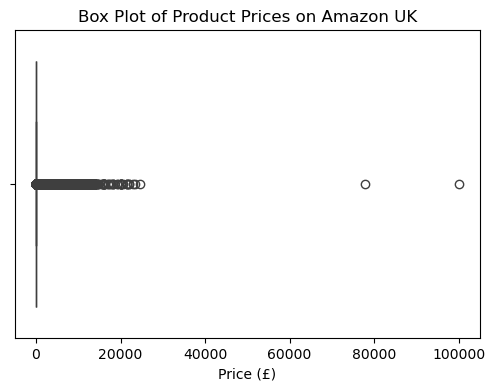

In [34]:
#2.3.
plt.figure(figsize=(6, 4))

sns.boxplot(x=df["price"])

plt.title("Box Plot of Product Prices on Amazon UK")
plt.xlabel("Price (£)")
plt.show()

The box plot reveals the presence of several high-priced outliers that lie far above the upper quartile. This indicates that while most products are priced within a relatively narrow range, a small number of products are priced significantly higher than the rest.

In [36]:
#3.1.1.
#Measures of Centrality
print( "mean rating: ", df['stars'].mean())
print( "median rating: ", df['stars'].median())
print( "mode rating: ", df['stars'].mode()[0])

mean rating:  2.152836472966065
median rating:  0.0
mode rating:  0.0


* The mode (0.0) indicates that most products have no ratings
* The median (0.0) confirms that at least half of products are unrated
* The mean (~2.15) suggests that when products are rated, ratings are moderate, not very high

In [38]:
#Measures of dispersion
print( "rating variance: ", df['stars'].var())
print( "rating std:", df['stars'].std())
print( "rating range", (df['stars'].max()) - (df['stars'].min()))

rating variance:  4.81743402976196
rating std: 2.1948653785054697
rating range 5.0


In [39]:
Q1 = df['stars'].quantile(0.25)
Q3 = df['stars'].quantile(0.75)
IQR = Q3 - Q1
Q1, Q3, IQR

(np.float64(0.0), np.float64(4.4), np.float64(4.4))

Customer ratings are highly variable, indicating a wide range of customer opinions rather than consistent feedback.

In [ ]:
#3.3.
#Shape of distribution
print(df['stars'].skew())
print(df['stars'].kurtosis())

0.08120735761080985
-1.9260061280432985


The ratings are fairly symmetric with no strong bias toward high or low values, but they are more spread out than a normal distribution, indicating diverse customer feedback.

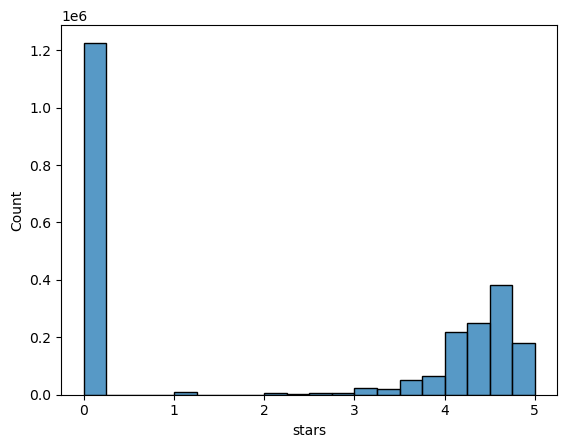

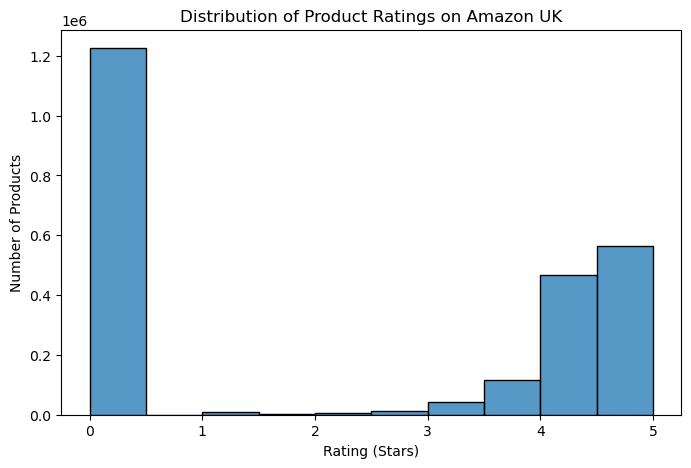

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(df['stars'], bins=10, kde=False)

plt.title("Distribution of Product Ratings on Amazon UK")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Products")
plt.show()

yes, The most common rating is 0 stars, as indicated by the highest bar in the histogram.

# summary
Overall, customer ratings on Amazon UK show a wide variation rather than being tightly consistent. While some products receive high ratings, a large number of listings have very low or even zero ratings, which pulls the average rating down. The most common rating value is 0, suggesting that many products may be newly listed or have not yet received customer feedback. The distribution is not perfectly normal and appears fairly flat, indicating mixed customer experiences rather than a strong tendency toward either very high or very low ratings. From a business perspective, this highlights the importance of gathering customer reviews early, as products without ratings may struggle to build trust and visibility on the platform.